<a href="https://colab.research.google.com/github/OuhmadMohamed/DI_Bootcamp/blob/main/Week7/Day2/Daily_Challenge_W7_D2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Daily Challenge: Classification with Neural Networks in TensorFlow**

# 1. Classification Types

***Binary Classification***

Binary classification involves predicting one of two possible classes.
Example: Email spam detection (spam vs not spam).

***Multi-class Classification***

Multi-class classification involves predicting one class out of more than two categories.
Example: Handwritten digit recognition (0–9).

***Multi-label Classification***

Multi-label classification assigns multiple labels to a single input.
Example: An image tagged as both “dog” and “outdoor”.


# 2. Dataset + Visualization

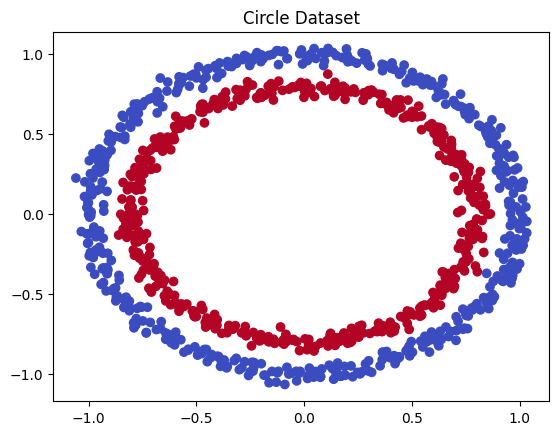

In [1]:
#Generate data
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

samples = 1000
X, y = make_circles(n_samples=samples, noise=0.03, random_state=42)
#Visualize
plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm")
plt.title("Circle Dataset")
plt.show()

# 3. Basic Neural Network

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Dense(1, input_shape=(2,))
])

model.compile(
    optimizer="sgd",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.fit(X, y, epochs=20)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4900 - loss: 6.4720
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4880 - loss: 6.3604
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5040 - loss: 6.0458
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4450 - loss: 5.6692 
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4600 - loss: 5.2564 
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4630 - loss: 5.0550
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5560 - loss: 4.9955 
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5480 - loss: 5.3642 
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5390 - loss: 5.3512 
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5420 - loss: 5.3498 
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5440 - loss: 5.3491 
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.54

# 4. Improve the Model

In [3]:
model = models.Sequential([
    layers.Dense(16, activation="relu", input_shape=(2,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.fit(X, y, epochs=100, verbose=0)

# 5. Decision Boundary Function

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


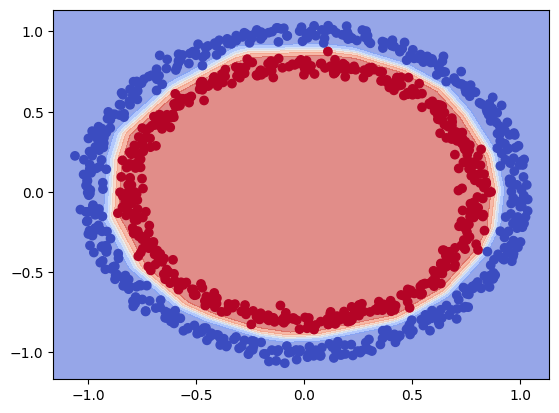

In [4]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:,0].min()-0.1, X[:,0].max()+0.1
    y_min, y_max = X[:,1].min()-0.1, X[:,1].max()+0.1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid)
    preds = preds.reshape(xx.shape)

    plt.contourf(xx, yy, preds, cmap="coolwarm", alpha=0.6)
    plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm")
    plt.show()
#Plot it
plot_decision_boundary(model, X, y)

# 6. Activation Functions

*   ReLU → helps learn complex patterns
*   Sigmoid → outputs probabilities (0–1)

Already used in improved model:

layers.Dense(16, activation="relu")

layers.Dense(1, activation="sigmoid")

# 7. Train/Test Split

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
#Train again
model.fit(X_train, y_train, epochs=100, verbose=0)


8. Evaluate Model

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0074  
Test accuracy: 1.0
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 964us/step


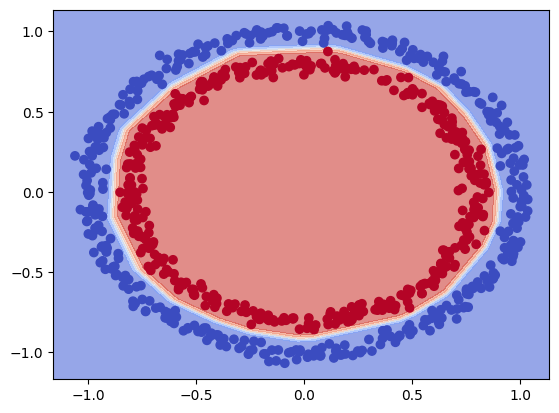

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 993us/step


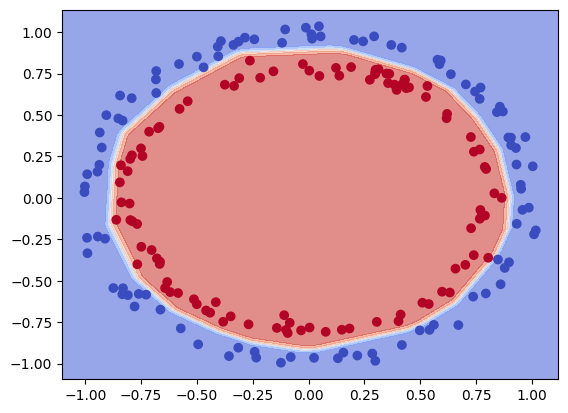

In [7]:
loss, acc = model.evaluate(X_test, y_test)
print("Test accuracy:", acc)
#Decision boundary (train vs test)
plot_decision_boundary(model, X_train, y_train)
plot_decision_boundary(model, X_test, y_test)


✅ 9. Final Summary

Neural networks can effectively solve classification problems, especially when the data is not linearly separable. Adding hidden layers and activation functions such as ReLU allows the model to learn complex patterns. Visualizing decision boundaries helps understand how the model separates different classes. Additionally, tuning hyperparameters such as the number of layers, neurons, and optimizer significantly improves performance. Splitting data into training and test sets ensures that the model generalizes well to unseen data.